# Model Project


## 1. A consumer with two nests

### 1.1 The problem in nested budget shares

##### Approach for Section 1.1

The consumer's problem is originally stated in quantities $(x_1, x_2, x_3)$
subject to the linear budget constraint

$$
p_1 x_1 + p_2 x_2 + p_3 x_3 = I,
$$

which a box-constrained solver like L-BFGS-B can't handle directly. Section
1.1 reparametrizes the choice into two numbers confined to $[0,1]$: $s_1$,
the share of income spent on food, and $w$, the share of the remaining
travel budget spent on the bus. The three budget shares then follow
automatically as

$$
s_1, \qquad s_2 = (1 - s_1) w, \qquad s_3 = (1 - s_1)(1 - w),
$$

which always sum to one, so the budget constraint holds for any choice in
the unit square — turning the constrained problem into a simple box
$[0,1] \times [0,1]$, exactly what L-BFGS-B takes as bounds, with no
penalty terms needed.

This mapping (`shares` and `quantities`) is already implemented in
`Consumer.py`, so our job is to understand why it works (linking to the
reparametrization idea from section 6.4 of the optimization lecture) and to
build the utility side of the problem on top of it:

- `utility(x1, x2, x3)` implements the nested CES formula

$$
x_B = \left[\beta x_2^{\rho_B} + (1-\beta) x_3^{\rho_B}\right]^{\frac{1}{\rho_B}},
\qquad
u(x_1, x_2, x_3) = \left[\alpha x_1^{\rho_A} + (1-\alpha) x_B^{\rho_A}\right]^{\frac{1}{\rho_A}},
$$

  combining goods 2 and 3 into the travel composite $x_B$ first, and then
  combining that with good 1.

- `value_of_choice(s1, w)` turns the nested shares into quantities using
  the given `quantities()` function and passes them to `utility()`, giving
  the objective that `solve_grid` and `solve` will later maximize.

In short, 1.1 sets up *what* is being maximized as a function of $(s_1, w)$,
not yet *how* it gets solved.

In [1]:
# Following code is from Consumer.py - We have added our own code when stated in the comments

from types import SimpleNamespace

import numpy as np

from scipy import optimize

class ConsumerClass:
    """ a consumer with nested CES preferences over three goods

    Good 1 is food. Goods 2 and 3 are bus trips and train trips, and they sit
    together in a nest.

    The problem is written in *nested* budget shares, in the same two steps as
    the nests themselves:

        s1 = the share of income spent on food
        w  = the share of the remaining (travel) budget spent on the bus

    so that s2 = (1-s1)*w and s3 = (1-s1)*(1-w). Any (s1,w) in the unit square
    is a possible choice, and every possible choice is in the unit square, so
    the constraint set is exactly the box that L-BFGS-B takes as `bounds`.

    """

    def __init__(self,par=None):

        # a. setup
        self.setup()

        # b. update parameters
        if not par is None:
            for k,v in par.items():
                self.par.__dict__[k] = v

    def setup(self):
        """ set the baseline parameters """

        par = self.par = SimpleNamespace()
        sol = self.sol = SimpleNamespace()

        # a. preference weights
        par.alpha = 0.60 # weight on food
        par.beta = 0.50 # weight on the bus

        # b. substitution
        par.sigma_A = 0.80 # between food and travel (upper nest)
        par.sigma_B = 0.40 # between bus and train (lower nest)

        # c. prices and income
        par.p1 = 1.0 # price of food
        par.p2 = 1.0 # price of a bus trip
        par.p3 = 1.5 # price of a train trip
        par.I = 10.0 # income

        # d. numerical settings
        par.s_min = 1e-12 # smallest quantity allowed in .ces(), see the note there

    def __str__(self):
        """ print the parameters """

        par = self.par

        lines = ['ConsumerClass']
        lines.append(f'  alpha = {par.alpha:.4f}, beta = {par.beta:.4f}')
        lines.append(f'  sigma_A = {par.sigma_A:.4f}, sigma_B = {par.sigma_B:.4f}')
        lines.append(f'  p1 = {par.p1:.4f}, p2 = {par.p2:.4f}, p3 = {par.p3:.4f}')
        lines.append(f'  I = {par.I:.4f}')

        return '\n'.join(lines)

    ###################
    # 1. the CES nest #
    ###################

    def ces(self,z1,z2,w,sigma):
        """ the CES aggregate of two inputs

        Computes (w*z1**rho + (1-w)*z2**rho)**(1/rho) with rho = 1-1/sigma.

        The inputs are floored at par.s_min, because z**rho is not defined for
        z = 0 when rho < 0, and the corners of the unit square do give zeros.

        Note on the size of par.s_min. It must be *far* below the step that
        L-BFGS-B uses to estimate the gradient, which is `eps` and about 1e-8 by
        default. Otherwise both z and z+eps get floored to the same number near a
        bound, utility comes out exactly equal in the two points, the estimated
        gradient is zero, and the solver stops on the bound and stays there. With
        s_min = 1e-8 that really happens: the answers in section 4 for high tax
        rates come out as zero revenue. 1e-12 is small enough to be invisible and
        large enough to keep z**rho from overflowing.

        Args:

            z1 (float or ndarray): first input
            z2 (float or ndarray): second input
            w (float): weight on the first input
            sigma (float): substitution parameter, must not be 1

        Returns:

            (float or ndarray): the CES aggregate

        """

        par = self.par

        assert not np.isclose(sigma,1.0), 'sigma = 1 gives rho = 0 and a division by zero'

        z1 = np.maximum(z1,par.s_min)
        z2 = np.maximum(z2,par.s_min)

        rho = 1-1/sigma

        return (w*z1**rho + (1-w)*z2**rho)**(1/rho)

    def utility(self,x1,x2,x3):
        """ nested CES utility of a bundle of quantities

        Two steps: first combine goods 2 and 3 into the travel composite, then
        combine good 1 and the composite into utility. Use .ces() for both.

        Args:

            x1 (float or ndarray): quantity of good 1
            x2 (float or ndarray): quantity of good 2
            x3 (float or ndarray): quantity of good 3

        Returns:

            (float or ndarray): utility

        """

        par = self.par

#-------------------------------------------------------------------------------------#
# WE NOW ADD OUR OWN CODE TO GENERATE THE TRAVEL COMPOSITE AND THE UTILITY 
        #pass

        par = self.par
        
        xB = self.ces(x2, x3, par.beta, par.sigma_B)
                
        u = self.ces(x1, xB, par.alpha, par.sigma_A)

        return u

#-------------------------------------------------------------------------------------#

    ###############################
    # 2. the nested budget shares #
    ###############################

    def shares(self,s1,w):
        """ the three budget shares implied by the nested shares

        Args:

            s1 (float or ndarray): share of income spent on food
            w (float or ndarray): share of the travel budget spent on the bus

        Returns:

            (tuple): the three budget shares, which always sum to one

        """

        return s1,(1-s1)*w,(1-s1)*(1-w)

    def quantities(self,s1,w):
        """ the quantities implied by the nested shares

        Args:

            s1 (float or ndarray): share of income spent on food
            w (float or ndarray): share of the travel budget spent on the bus

        Returns:

            (tuple): the three quantities

        """

        par = self.par

        s1,s2,s3 = self.shares(s1,w)

        return s1*par.I/par.p1, s2*par.I/par.p2, s3*par.I/par.p3

    def value_of_choice(self,s1,w):
        """ utility of the bundle implied by the nested shares

        Args:

            s1 (float or ndarray): share of income spent on food
            w (float or ndarray): share of the travel budget spent on the bus

        Returns:

            (float or ndarray): utility

        """

#-------------------------------------------------------------------------------------#
# WE NOW ADD OUR OWN CODE. INSTEAD OF CHOOSING QUANTITIES, WE CHOOSE BUDGET SHARES. 

        #pass
        x1, x2, x3 = self.quantities(s1, w)
        u = self.utility(x1, x2, x3)

        return u
#-------------------------------------------------------------------------------------#

    def objective(self,s):
        """ minus utility, for a minimizer

        Nothing else is needed: the bounds are the whole constraint.

        Args:

            s (ndarray): array of length 2 with (s1,w)

        Returns:

            (float): minus utility

        """

        return -self.value_of_choice(s[0],s[1])

    #################
    # 3. solving it #
    #################

    def solve_grid(self,N=200,do_print=True):
        """ solve by a 2-dimensional grid search over the nested shares

        Every point of the unit square is a possible choice, so there is nothing
        to mask out here -- a plain np.argmax will do.

        Args:

            N (int): number of grid points for each variable
            do_print (bool): print the solution

        Returns:

            (SimpleNamespace): the grids, the utility values and the best point

        """

        par = self.par
        opt = SimpleNamespace()

#-------------------------------------------------------------------------------------#
# WE NOW ADD OUR OWN CODE. 

        # a. the two grids
        #pass
        s1_vec = np.linspace(0, 1, N)
        w_vec = np.linspace(0, 1, N)
    
        opt.s1_grid, opt.w_grid = np.meshgrid(
                s1_vec, w_vec, indexing='ij'
             )

        # b. utility in every grid point
        #pass
        opt.u_grid = self.value_of_choice(
                    opt.s1_grid,
                    opt.w_grid
                )

        # c. the best point
        #pass
        idx = np.unravel_index(
                   np.argmax(opt.u_grid),
                   opt.u_grid.shape
                )
        
        opt.s1 = opt.s1_grid[idx]
        opt.w = opt.w_grid[idx]
        
        opt.s2 = (1 - opt.s1) * opt.w
        opt.s3 = (1 - opt.s1) * (1 - opt.w)
        
        opt.u = opt.u_grid[idx]
    

        # d. results
        # opt.s1, opt.w, opt.s2, opt.s3, opt.u
        # opt.s1_grid, opt.w_grid, opt.u_grid (needed for the figures)

        return opt

#-------------------------------------------------------------------------------------#

    def solve(self,s0=None,do_print=True,**kwargs):
        """ solve with L-BFGS-B

        The bounds are ((0,1),(0,1)) -- the whole constraint set.

        Args:

            s0 (ndarray): starting guess for (s1,w)
            do_print (bool): print the solution
            kwargs: passed on to optimize.minimize, e.g. options={'ftol':1e-10}

        Returns:

            (SimpleNamespace): the solution and the convergence path

        """

        par = self.par
        opt = SimpleNamespace()

        # a. starting guess
        if s0 is None: s0 = np.array([0.5,0.5])
        s0 = np.asarray(s0,dtype=float)

        # b. record the path with a callback
        path = [s0.copy()]

#-------------------------------------------------------------------------------------#
# WE NOW ADD OUR OWN CODE
        # c. minimize
        #pass
        res = optimize.minimize(
               self.objective,
               s0,
               method='L-BFGS-B',
               bounds=((0,1),(0,1)),
               callback=lambda sk: path.append(sk.copy()),
               **kwargs
            )

        # d. results
        # opt.s1, opt.w, opt.s2, opt.s3, opt.u, opt.path, opt.res
        opt.s1 = res.x[0]
        opt.w = res.x[1]
        opt.s2 = (1 - opt.s1) * opt.w
        opt.s3 = (1 - opt.s1) * (1 - opt.w)
        opt.u = -res.fun
        opt.path = path
        opt.res = res

        return opt

#-------------------------------------------------------------------------------------#

In [2]:
# Testing 1.1 with grid
model = ConsumerClass()

grid_sol = model.solve_grid(N=500)

print("Grid solution:")
print("s1 =", grid_sol.s1)
print("w  =", grid_sol.w)
print("s2 =", grid_sol.s2)
print("s3 =", grid_sol.s3)
print("u  =", grid_sol.u)

Grid solution:
s1 = 0.5350701402805611
w  = 0.438877755511022
s2 = 0.20404737330372166
s3 = 0.26088248641571726
u  = 3.40167436585882


In [3]:
# Comparing with L-BFGS-B
sol = model.solve()

print("\nL-BFGS-B solution:")
print("s1 =", sol.s1)
print("w  =", sol.w)
print("s2 =", sol.s2)
print("s3 =", sol.s3)
print("u  =", sol.u)


L-BFGS-B solution:
s1 = 0.5356233806953101
w  = 0.43947902810370126
s2 = 0.20408378532610758
s3 = 0.26029283397858227
u  = 3.401679875985606


The two different methods Grid solution and L-BFGS-B solution agree

### 1.2 Calibration


##### Approach for Section 1.2

Section 1.2 does not require new code, only running the existing model under
two calibrations that differ solely in $\sigma_B$: $\sigma_B = 0.40$ (bus and
train as complements) versus $\sigma_B = 3.00$ (substitutes), with all other
parameters held fixed. Since `ConsumerClass` already accepts a `par`
dictionary that overwrites only the given keys, the second calibration costs
one extra line,

```python
model_substitutes = ConsumerClass(par={'sigma_B': 3.0})
```

and every later step (solving, printing, plotting) can loop over both models
instead of duplicating code.


In short, the first model uses the parameter sigma_B = 0.40.
The second model changes to sigma_B = 3.0. While all the other parameters remain the same.

In [45]:
# Calibration 1: Complements
model_comp = ConsumerClass(par={'sigma_B': 0.4})

# Calibration 2: Substitutes 
model_sub = ConsumerClass(par={'sigma_B': 3.0})

We can now check wheather the calibrations are correct

In [46]:
print("Complements:")
print(model_comp)

print("\nSubstitutes:")
print(model_sub)

Complements:
ConsumerClass
  alpha = 0.6000, beta = 0.5000
  sigma_A = 0.8000, sigma_B = 0.4000
  p1 = 1.0000, p2 = 1.0000, p3 = 1.5000
  I = 10.0000

Substitutes:
ConsumerClass
  alpha = 0.6000, beta = 0.5000
  sigma_A = 0.8000, sigma_B = 3.0000
  p1 = 1.0000, p2 = 1.0000, p3 = 1.5000
  I = 10.0000


The model is solved for both calibrations. The two calibrations are identical except for the substituion parameter between bus and train, sigma_B. In the first calibration, we have sigma_B = 0.40, which means the bus and train are complements. In the second calibration, sigma_B = 3.00, so bus and train are substitutes. Note that the second calibration is produced by changing the value of sigma_B. While all the other preference, parameters, prices, and income remain unchanged.

### 1.3 How do you know your answer is right?

##### Approach for section 1.3
Since there is no formula for the solution of this model, we cannot look the answer up. Instead we can check the answer with two different approaches:

1. Is the answer possible? All three shares should be strictly between 0 and 1 and
sum to one, and all three quantities should be positive.


2. Do two different methods agree? In section 2 you solve the same problem
twice.

##### Approach 1 - Is the answer possible

In [4]:
# Check that the solution is possible

print("Budget shares:")
print("s1 =", sol.s1)
print("s2 =", sol.s2)
print("s3 =", sol.s3)

print("\nSum of shares:")
print(sol.s1 + sol.s2 + sol.s3)

print("\nQuantities:")
x1, x2, x3 = model.quantities(sol.s1, sol.w)

print("x1 =", x1)
print("x2 =", x2)
print("x3 =", x3)

Budget shares:
s1 = 0.5356233806953101
s2 = 0.20408378532610758
s3 = 0.26029283397858227

Sum of shares:
1.0

Quantities:
x1 = 5.356233806953101
x2 = 2.040837853261076
x3 = 1.7352855598572152


Since all budget shares $0<s<1$, all quantites is positive, and the sum of shares = 1, the solution is possible

We can also check the conditions seperatly:

In [5]:
# We check whether the budget shares are in the interval (0,1)

0 < sol.s1 < 1
0 < sol.s2 < 1
0 < sol.s3 < 1

np.True_

In [6]:
# We check whether the budget shares sum to 1

sol.s1 + sol.s2 + sol.s3

np.float64(1.0)

In [7]:
# We check whether the quantities are positive

x1 > 0
x2 > 0
x3 > 0

np.True_

In [8]:
# We can also use the following code to check whether the solution is possible

print("All shares between 0 and 1:",
      0 < sol.s1 < 1 and
      0 < sol.s2 < 1 and
      0 < sol.s3 < 1)

print("Shares sum to 1:",
      np.isclose(sol.s1 + sol.s2 + sol.s3, 1))

print("All quantities positive:",
      x1 > 0 and x2 > 0 and x3 > 0)

All shares between 0 and 1: True
Shares sum to 1: True
All quantities positive: True


NB: Hey TA - Which of the solutions above is preferred? 

##### Approach 2 - Do two different methods agree? 

Hey TA - In our group we discussed whether this question really belonged to Part 2. Solving the model numerically? - But we have tried to answer the question anymay - Is our interpretation and answer of the question correct?

In [9]:
# We have interpreted the question as: Do the methods grid search and L-BFGS-B agree.

grid_sol = model.solve_grid(N=1000)
sol = model.solve()

# Grid search:
print("Grid search:")
print("s1 =", grid_sol.s1)
print("w  =", grid_sol.w)
print("u  =", grid_sol.u)

# L-BFGS-B optimization:
print("\nL-BFGS-B:")
print("s1 =", sol.s1)
print("w  =", sol.w)
print("u  =", sol.u)

Grid search:
s1 = 0.5355355355355356
w  = 0.4394394394394394
u  = 3.4016797975402664

L-BFGS-B:
s1 = 0.5356233806953101
w  = 0.43947902810370126
u  = 3.401679875985606


The grid search only consider a finite number of points, so its result will not necessary be identical to L-BFGS-B. But with a sufficient fine grid, the results should be almost identical. 

In [10]:
# Calculating the difference 

print("Difference in s1:",
      abs(grid_sol.s1 - sol.s1))

print("Difference in w:",
      abs(grid_sol.w - sol.w))

print("Difference in utility:",
      abs(grid_sol.u - sol.u))

Difference in s1: 8.784515977455776e-05
Difference in w: 3.958866426184704e-05
Difference in utility: 7.844533955747579e-08


The solution passes both checks. All three budget shares are strictly between 0 and 1 and sum to one, which satisfies the budget constraint. The corresponding quantities of food, bus trips, and train trips are all positive. The grid search and L-BFGS-B methods produce a very similar optimal shares and utility levels (So the two different methods do more or less agree). Since two independent numerical methods arrive at approximately the same solution, this provides strong evidence that the numerical solution is correct.

## 2. Solving the model numerically
We solve eq. 4 (utility maximization) twice, in two very different ways: A two dimentional grid search and a L-BFGS-B

A two-dimensional grid search is a method for finding the best combination of two parameters by evaluating a function at every point on a systematic grid of values for both parameters and picking the combination with the best result. It's simple and robust (no risk of getting stuck via gradients), but computationally expensive as the grid gets finer or more parameters are added.

L-BFGS-B is a quasi-Newton optimization algorithm that efficiently finds a function's minimum by approximating the Hessian (second derivative) from recent gradient updates rather than computing it directly, using limited memory to stay efficient in high dimensions ("L"), while also supporting simple bound constraints on the variables ("B"). It's often used to fine-tune a solution quickly once a grid search has located roughly the right region.


### 2.1 A two-dimensional grid search

##### Approach for 2.1
In 2.1 we solve the utility maximization problem with a two-dimensional grid search. We lay a grid over everything the consumer can afford, compute utility in every point, and keep the best one.



 by the following approach

1. Create two vectors of `N` points between 0 and 1 — one for `s_1` and one for `w`.
2. Create a 2D grid of all combinations using `np.meshgrid(..., indexing='ij')`.
3. Calculate utility at **all** grid points at once (vectorized, so no loop is needed, because `ces()`, `utility()`, and `value_of_choice()` already work with arrays).
4. Find the best point using `np.argmax` + `np.unravel_index`.
5. Report both `(s_1, w)` and the three implied budget shares `(s_1, s_2, s_3)`.

##### 2.1.1
Make a grid of N values of s1 and N values of w, both from 0 to 1, compute utility in every combination, and keep the best point. Implement it as solve_grid
(). Report both (s1, w) and the three budget shares it implies.
Hint: np.meshgrid(s1_vec,w_vec,indexing=’ij’) builds the grid, and np.argmax
together with np.unravel_index finds the best point. Note that there is nothing
to mask out and no np.nan anywhere: every point of the square is a possible
choice.

In [11]:
# Solve the model for different grid sizes 50, 100, 500, and 1000
model = ConsumerClass()

for N in [50, 100, 500, 1000]:
    sol_grid = model.solve_grid(N=N)

    print(f"N = {N}")
    print(f"s1 = {sol_grid.s1:.6f}")
    print(f"w  = {sol_grid.w:.6f}")
    print(f"s2 = {sol_grid.s2:.6f}")
    print(f"s3 = {sol_grid.s3:.6f}")
    print(f"u  = {sol_grid.u:.6f}")
    print()

N = 50
s1 = 0.530612
w  = 0.448980
s2 = 0.210746
s3 = 0.258642
u  = 3.400748

N = 100
s1 = 0.535354
w  = 0.444444
s2 = 0.206510
s3 = 0.258137
u  = 3.401482

N = 500
s1 = 0.535070
w  = 0.438878
s2 = 0.204047
s3 = 0.260882
u  = 3.401674

N = 1000
s1 = 0.535536
w  = 0.439439
s2 = 0.204104
s3 = 0.260360
u  = 3.401680



The grid results does not necessarily improve smoothly. The optimum can jump from one grid point to another as N increase.

In [12]:
# We now implement the hint 

def solve_grid(self,N=200,do_print=True):
    """ solve by a 2-dimensional grid search over the nested shares

    Every point of the unit square is a possible choice, so there is nothing
    to mask out here -- a plain np.argmax will do.
    """

    par = self.par
    opt = SimpleNamespace()

    # a. the two grids
    s1_vec = np.linspace(0, 1, N)
    w_vec = np.linspace(0, 1, N)

    opt.s1_grid, opt.w_grid = np.meshgrid(
        s1_vec,
        w_vec,
        indexing='ij'
    )

    # b. utility in every grid point
    opt.u_grid = self.value_of_choice(
        opt.s1_grid,
        opt.w_grid
    )

    # c. the best point
    idx = np.argmax(opt.u_grid)

    i, j = np.unravel_index(
        idx,
        opt.u_grid.shape
    )

    # d. results
    opt.s1 = opt.s1_grid[i, j]
    opt.w = opt.w_grid[i, j]

    opt.s2 = (1 - opt.s1) * opt.w
    opt.s3 = (1 - opt.s1) * (1 - opt.w)

    opt.u = opt.u_grid[i, j]

    if do_print:
        print(f"s1 = {opt.s1:.6f}")
        print(f"w  = {opt.w:.6f}")
        print(f"s2 = {opt.s2:.6f}")
        print(f"s3 = {opt.s3:.6f}")
        print(f"u  = {opt.u:.6f}")

    return opt

In [13]:
# Solve the model for different grid sizes 50, 100, 500, and 1000
model = ConsumerClass()

for N in [50, 100, 500, 1000]:

    sol = model.solve_grid(N=N)

    print(f"\nN = {N}")
    print(f"s1 = {sol.s1:.6f}")
    print(f"w  = {sol.w:.6f}")
    print(f"s2 = {sol.s2:.6f}")
    print(f"s3 = {sol.s3:.6f}")
    print(f"u  = {sol.u:.6f}")


N = 50
s1 = 0.530612
w  = 0.448980
s2 = 0.210746
s3 = 0.258642
u  = 3.400748

N = 100
s1 = 0.535354
w  = 0.444444
s2 = 0.206510
s3 = 0.258137
u  = 3.401482

N = 500
s1 = 0.535070
w  = 0.438878
s2 = 0.204047
s3 = 0.260882
u  = 3.401674

N = 1000
s1 = 0.535536
w  = 0.439439
s2 = 0.204104
s3 = 0.260360
u  = 3.401680


We get the same results

##### 2.1.2

Plot utility over the nested shares in 3D (ax = fig.add_subplot(1,2,1,projection
=’3d’) and ax.plot_surface) and as a contour plot (ax.contourf), with the
solution marked.

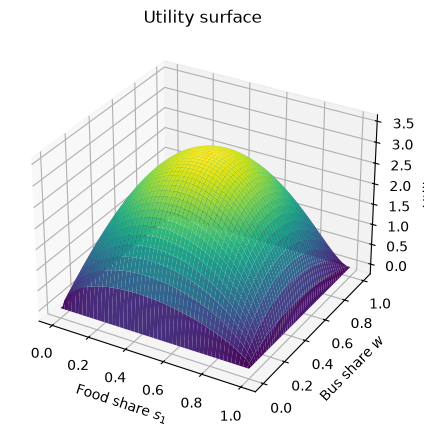

In [14]:
# plot the utility surface and the optimal point
import matplotlib.pyplot as plt

model = ConsumerClass()

grid_sol = model.solve_grid(N=100)

fig = plt.figure(figsize=(12, 5))

ax = fig.add_subplot(1, 2, 1, projection='3d')

ax.plot_surface(
    grid_sol.s1_grid,
    grid_sol.w_grid,
    grid_sol.u_grid,
    cmap='viridis'
)

ax.scatter(
    grid_sol.s1,
    grid_sol.w,
    grid_sol.u,
    color='red',
    s=50
)

ax.set_xlabel('Food share $s_1$')
ax.set_ylabel('Bus share $w$')
ax.set_zlabel('Utility')
ax.set_title('Utility surface')

plt.show()

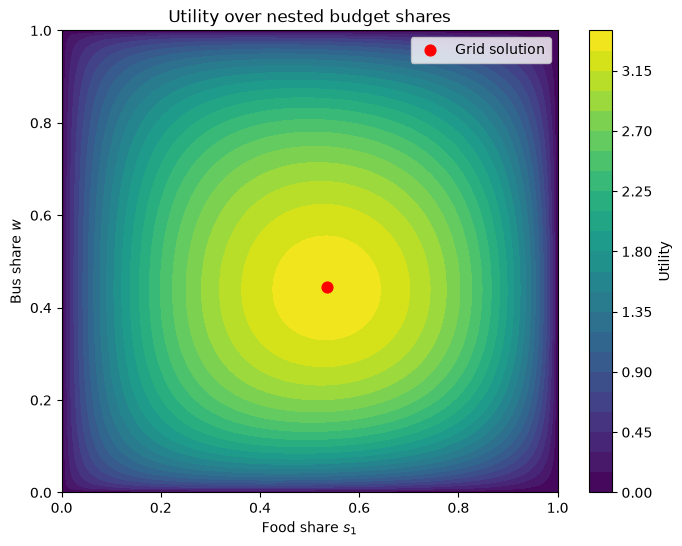

In [15]:
# plot the utility contour and the optimal point
fig, ax = plt.subplots(figsize=(8, 6))

contour = ax.contourf(
    grid_sol.s1_grid,
    grid_sol.w_grid,
    grid_sol.u_grid,
    levels=30
)

ax.scatter(
    grid_sol.s1,
    grid_sol.w,
    color='red',
    s=60,
    label='Grid solution'
)

ax.set_xlabel('Food share $s_1$')
ax.set_ylabel('Bus share $w$')
ax.set_title('Utility over nested budget shares')

plt.colorbar(contour, ax=ax, label='Utility')
ax.legend()

plt.show()

##### 2.1.3

Try N = 50, 100, 500 and 1000. How much does the answer move when you
add points, and how many evaluations of u does it cost? Does it improve
smoothly?

The output of the grid search for grid sizes 50, 100, 500, and 1000 is as follows:

N = 50
s1 = 0.530612
w  = 0.448980
s2 = 0.210746
s3 = 0.258642
u  = 3.400748

N = 100
s1 = 0.535354
w  = 0.444444
s2 = 0.206510
s3 = 0.258137
u  = 3.401482

N = 500
s1 = 0.535070
w  = 0.438878
s2 = 0.204047
s3 = 0.260882
u  = 3.401674

N = 1000
s1 = 0.535536
w  = 0.439439
s2 = 0.204104
s3 = 0.260360
u  = 3.401680

The grid search becomes more precise as N increases. The optimal values of s1 and w change when N increase. But the computational cost increases rapidly during to the number of the utility evaluations is N^(2). For eksempel N=50: 2500, N=100: 10.000 and so on. 

Does it improve smoothly? The solution does not necessarily improve smoothly. Since the grid accounts only for discrete points, the estimated optimum can jump between grid points as N changes. However, as the grid becomes finer, the changes generally become smaller which indicating convergence toward the numerical optimum. 

##### 2.1.4

Compare the two calibrations. Where is the surface steep, and where is it flat?
Which of the two would you expect to be harder for an optimizer?

In [17]:
# Define the model with complements and substitutes

# Complements: sigma = 0.4
model_comp = ConsumerClass()
sigma_B = 0.40

# Substitutes: sigma = 3.0
model_sub = ConsumerClass(
    par={'sigma_B': 3.0}
)

In [18]:
# Solve the models
comp_sol = model_comp.solve_grid(N=500)
sub_sol = model_sub.solve_grid(N=500)

print("COMPLEMENTS")
print("s1 =", comp_sol.s1)
print("w  =", comp_sol.w)
print("s2 =", comp_sol.s2)
print("s3 =", comp_sol.s3)
print("u  =", comp_sol.u)

print("\nSUBSTITUTES")
print("s1 =", sub_sol.s1)
print("w  =", sub_sol.w)
print("s2 =", sub_sol.s2)
print("s3 =", sub_sol.s3)
print("u  =", sub_sol.u)

COMPLEMENTS
s1 = 0.5350701402805611
w  = 0.438877755511022
s2 = 0.20404737330372166
s3 = 0.26088248641571726
u  = 3.40167436585882

SUBSTITUTES
s1 = 0.5390781563126252
w  = 0.691382765531062
s2 = 0.31867341898225304
s3 = 0.14224842470512172
u  = 3.4850971386959047


##### Interpretation

For the complements calibration, bus and train are difficult to substitute for each other during to sigma_B = 0.4 < 1. So, the consumer wants a combination of bus and train.

For the substitutes calibration. sigma_B = 3 > 1. Bus and train are easier to substitute, so the consumer has a greater incentive to shift over to the cheaper travel option. 

Where is the surface steep, and where is it flat?
A steep surface part means that the changes in utility is relatively large when s1 or w changes.

A flat surface part means that the changes in utility is very small when s1 or w changes. 

For the complements calibration:
Bus and train trips are more dependent on each other. Because they are consumed together, the utility changes more strongly when the share of one transportation good becomes very small. This makes the utility surface more steeper and curved, especially near the boundaries. 

For the substitutes calibration: 
Bus and train trips are easier to substitute for one another. Why, shifting the travel budget from bus to train or vice versa has a smaller effect on the utility. This makes the utility surface flatter in the travel share direction. 

The two calibrations leads to a noticeable different utility surfaces. When bus and train are complements (sigma_B = 0.40), the surface is more curved, especially when the share of one travel good is close to zero. On the contrary, for the substitutes (sigma_B = 3.00), the surface is flatter in the w-direction, during to the consumers can switch easily between bus and train without a significant change in the utility. Therefore, we can say that the substitutes calibration is more likely difficult for a gradient based optimizer, because the flatter surface produces a smaller change in the utility and weaker gradients around the optimum. 


### 2.2 L-BFGS-B

##### 2.2.1
Solve the problem with L-BFGSS-B and implement it as solve(). Compare the solution,
the number of function evaluations and the running time with the grid
search. Do the two methods agree?

In [19]:
# Solve the model with L-BFGS-B
model = ConsumerClass()

sol = model.solve()

print("L-BFGS-B solution")
print("s1 =", sol.s1)
print("w  =", sol.w)
print("s2 =", sol.s2)
print("s3 =", sol.s3)
print("u  =", sol.u)

L-BFGS-B solution
s1 = 0.5356233806953101
w  = 0.43947902810370126
s2 = 0.20408378532610758
s3 = 0.26029283397858227
u  = 3.401679875985606


In [20]:
method='L-BFGS-B'

In [21]:
bounds=((0,1),(0,1))

In [22]:
# Solve the models with Grid search and L-BFGS-B and compare the results.

grid_sol = model.solve_grid(N=1000)
sol = model.solve()

print("Grid search")
print("s1 =", grid_sol.s1)
print("w  =", grid_sol.w)
print("u  =", grid_sol.u)

print("\nL-BFGS-B")
print("s1 =", sol.s1)
print("w  =", sol.w)
print("u  =", sol.u)

print("\nDifferences")
print("s1 difference =", abs(grid_sol.s1 - sol.s1))
print("w difference  =", abs(grid_sol.w - sol.w))
print("u difference  =", abs(grid_sol.u - sol.u))

Grid search
s1 = 0.5355355355355356
w  = 0.4394394394394394
u  = 3.4016797975402664

L-BFGS-B
s1 = 0.5356233806953101
w  = 0.43947902810370126
u  = 3.401679875985606

Differences
s1 difference = 8.784515977455776e-05
w difference  = 3.958866426184704e-05
u difference  = 7.844533955747579e-08


We observe that the two solution are very close, although the grid solution may not be exactly identical during to it only points what are on the grid. So we can say that the two method do more or less agree. The L-BFGS-B solution should be more preise and better than a grid. Because it uses the gradient information to search for the optimum rather than evaluating utility at every point on a grid. 

##### 2.2.2
Record the convergence path with the callback argument of optimize.minimize
, and draw it on top of the contour plot from section 2.1. Then plot how far each
iteration is from the point the solver ends at, against the iteration number, on a
log scale. Where does the method make fast progress, and where is it slow?

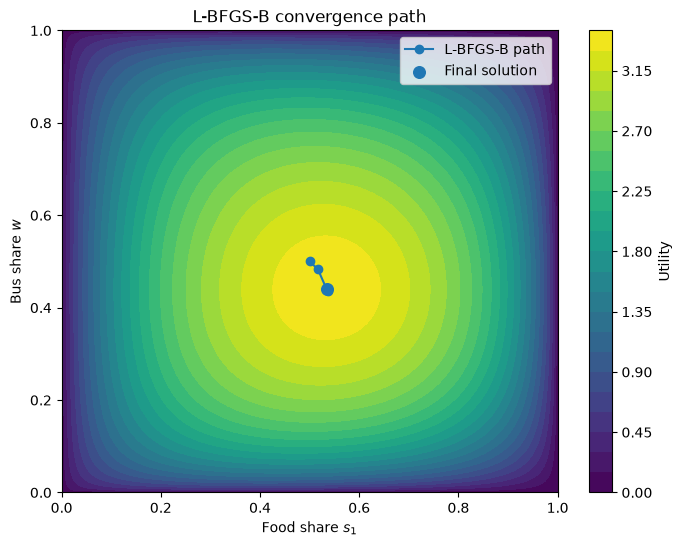

In [23]:
# Plot the utility contour and the optimal point with convergence path.

grid_sol = model.solve_grid(N=200)
sol = model.solve()

fig, ax = plt.subplots(figsize=(8, 6))

contour = ax.contourf(
    grid_sol.s1_grid,
    grid_sol.w_grid,
    grid_sol.u_grid,
    levels=30
)

path = np.array(sol.path)

ax.plot(
    path[:, 0],
    path[:, 1],
    marker='o',
    label='L-BFGS-B path'
)

ax.scatter(
    sol.s1,
    sol.w,
    s=70,
    label='Final solution'
)

ax.set_xlabel('Food share $s_1$')
ax.set_ylabel('Bus share $w$')
ax.set_title('L-BFGS-B convergence path')

plt.colorbar(contour, ax=ax, label='Utility')
ax.legend()

plt.show()

This shows the distance from final solution on a log scale

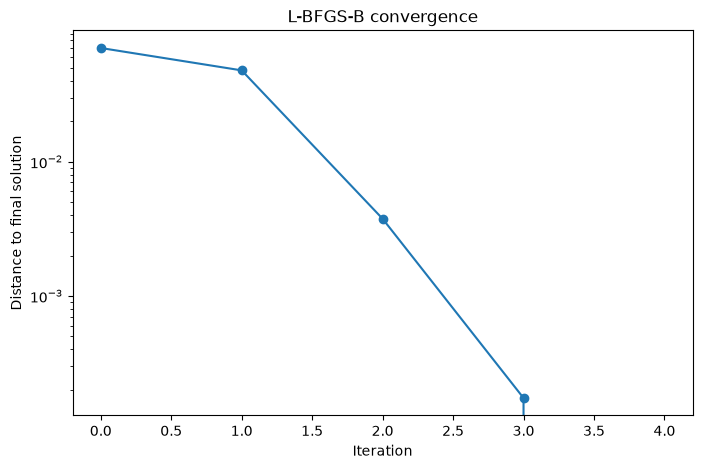

In [24]:
# Plot the distance to the final solution over iterations
path = np.array(sol.path)

distance = np.sqrt(
    (path[:, 0] - sol.s1)**2 +
    (path[:, 1] - sol.w)**2
)

plt.figure(figsize=(8, 5))

plt.plot(
    range(len(distance)),
    distance,
    marker='o'
)

plt.yscale('log')

plt.xlabel('Iteration')
plt.ylabel('Distance to final solution')
plt.title('L-BFGS-B convergence')

plt.show()

Interpretation: The algorithm is converging, and the distance is approximately falling toward zero.

The decline stating out flat which means the optimizer is making a slower progress, and then the decline turn out to be more steep, which means the optimizer is making a fast progress toward the solution.

##### 2.2.3

Solve from at least six different starting points, including the middle (1/2, 1/2)
and all four corners of the square. Do you always get the same answer? Does
the number of iterations change?

In [25]:
# Try different starting points for the L-BFGS-B solver.
starting_points = [
    [0.5, 0.5],
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0],
    [0.25, 0.75]
]

for s0 in starting_points:

    sol = model.solve(s0=s0)

    print(
        f"s0={s0} -> "
        f"s1={sol.s1:.6f}, "
        f"w={sol.w:.6f}, "
        f"u={sol.u:.6f}, "
        f"iterations={len(sol.path)-1}, "
        f"success={sol.res.success}"
    )

s0=[0.5, 0.5] -> s1=0.535623, w=0.439479, u=3.401680, iterations=4, success=True
s0=[0.0, 0.0] -> s1=0.535624, w=0.439478, u=3.401680, iterations=7, success=True
s0=[0.0, 1.0] -> s1=0.535624, w=0.439478, u=3.401680, iterations=9, success=True
s0=[1.0, 0.0] -> s1=0.999991, w=0.000000, u=0.000000, iterations=1, success=True
s0=[1.0, 1.0] -> s1=0.999991, w=1.000000, u=0.000000, iterations=1, success=True
s0=[0.25, 0.75] -> s1=0.535624, w=0.439479, u=3.401680, iterations=6, success=True


This shows whether L-BFGS-B finds the same optimum regardless of where it starts, so we will always get the same answer. 

##### 2.2.4
Vary the settings below -- they all go in options={...} -- and report the two
shares, the utility reached and the number of function evaluations for each of
them in one table:
(a) ftol (stop when the objective stops changing): 10^(−4)
, 10^(−8)
, 10^(−12), 10^(−16)
(b) gtol (stop when the gradient is small): 10^(−2)
, 10^(−5)
, 10^(−8)
, 10^(−12)

Compare ftol

In [27]:
# Try different ftol values for the L-BFGS-B solver.
ftol_values = [1e-4, 1e-8, 1e-12, 1e-16]

for ftol in ftol_values:

    sol = model.solve(
        options={'ftol': ftol}
    )

    print(
        f"ftol={ftol:.0e}: "
        f"s1={sol.s1:.8f}, "
        f"w={sol.w:.8f}, "
        f"u={sol.u:.8f}, "
        f"function evaluations={sol.res.nfev}"
    )

ftol=1e-04: s1=0.53560667, w=0.43965199, u=3.40167963, function evaluations=15
ftol=1e-08: s1=0.53562338, w=0.43947903, u=3.40167988, function evaluations=18
ftol=1e-12: s1=0.53562338, w=0.43947903, u=3.40167988, function evaluations=18
ftol=1e-16: s1=0.53562338, w=0.43947903, u=3.40167988, function evaluations=18


Compare gtol

In [28]:
# Try different gtol values for the L-BFGS-B solver.
gtol_values = [1e-2, 1e-5, 1e-8, 1e-12]

for gtol in gtol_values:

    sol = model.solve(
        options={'gtol': gtol}
    )

    print(
        f"gtol={gtol:.0e}: "
        f"s1={sol.s1:.8f}, "
        f"w={sol.w:.8f}, "
        f"u={sol.u:.8f}, "
        f"function evaluations={sol.res.nfev}"
    )

gtol=1e-02: s1=0.53560667, w=0.43965199, u=3.40167963, function evaluations=15
gtol=1e-05: s1=0.53562338, w=0.43947903, u=3.40167988, function evaluations=18
gtol=1e-08: s1=0.53562357, w=0.43947843, u=3.40167988, function evaluations=21
gtol=1e-12: s1=0.53562357, w=0.43947843, u=3.40167988, function evaluations=21


##### 2.2.5
Which settings would you use? Note that you can rank them without knowing
the true answer: we are maximizing, so a higher utility is a better answer.
Why is a tighter tolerance not always a better answer?

**2.1 Grid search:**

We solved the consumer's problem using a two-dimensional grid search over the nested budget share s_1 and w. We used grid with 50, 100, 500 and 1000 points for each variable. As the grid becomes finer, the solution will be more precise, during to more possible combinations of the two shares are evaluated. However the computational cost increases rapidly because the evaluations number is N^2

**2.2 L-BFGS-B:**

Afterwards we solved the same problem by using the L-BFGS-B optimization algorithm. The feasible set is [0,1]x[0,1], so the two nested shares can be used directly as the optimization variables. The L-BFGS-B solution is very close to the grid-search solution, which confirms the numerical result. 

**Convergence:**

The convergence path shows how L-BFGS-B approximate toward the optimum from the initial value. The distance to the final solution generally decreases over the ITERATIONS. The optimizer makes the fastest progress when it is far from the optimum and slows down as it approaches the solution.

**Starting values:**

We tested several different starting values, including the center and all four corners of the feasible region. By Comparing the results shows whether the optimizer consistently finds the same solution. Differences in convergence speed can occur even when the final solution is the same. 

**Tolerances:** 
A stricter tolerance makes the optimizer to find a more preicise solution, which means it needs more iterations and function evaluations. However, making the tolerance very small does not necessarily improve the result significantly. It can instead increase computation time without providing a meaningful gain in accuracy. 


## 3. Relative prices and demand

### 3.1 Train prices, budget shares and quantities

We now let the price of train trips, p3, vary from 0.5 to 3.0, while p1, p2 and income are held fixed. We solve the model for each value of p3 for both the complements and substitutes calibration.

We first import the packages and functions needed for the analysis.

In [29]:
from types import SimpleNamespace

import numpy as np

from scipy import optimize

import matplotlib.pyplot as plt

from Consumer import ConsumerClass

We run the notebook containing the consumer model so that the model can be used in the analysis below. The output is suppressed to avoid repeating results from the previous part.

We create a grid of train prices from 0.5 to 3.0 and define the two calibrations used in the analysis.

In [30]:
p3_vec = np.linspace(0.5, 3.0, 100)

model = ConsumerClass()
model_sub = ConsumerClass(par={'sigma_B': 3.0})

First, we solve the model for the complements calibration. For each value of `p3`, we store the optimal budget shares and the corresponding quantities.

In [31]:
# Complements

s1_comp = []
s2_comp = []
s3_comp = []

x1_comp = []
x2_comp = []
x3_comp = []

for p3 in p3_vec:

    model.par.p3 = p3
    sol = model.solve()

    s1_comp.append(sol.s1)
    s2_comp.append(sol.s2)
    s3_comp.append(sol.s3)

    x1, x2, x3 = model.quantities(sol.s1, sol.w)

    x1_comp.append(x1)
    x2_comp.append(x2)
    x3_comp.append(x3)


We repeat the same procedure for the substitutes calibration. The only difference between the two models is the value of `sigma_B`.


In [32]:
# Substitutes

s1_sub = []
s2_sub = []
s3_sub = []

x1_sub = []
x2_sub = []
x3_sub = []

for p3 in p3_vec:

    model_sub.par.p3 = p3
    sol_sub = model_sub.solve()

    s1_sub.append(sol_sub.s1)
    s2_sub.append(sol_sub.s2)
    s3_sub.append(sol_sub.s3)

    x1, x2, x3 = model_sub.quantities(sol_sub.s1, sol_sub.w)

    x1_sub.append(x1)
    x2_sub.append(x2)
    x3_sub.append(x3)

Finally, we plot the budget shares and quantities against the train price for both calibrations. This makes it possible to compare how demand changes when `p3` increases.

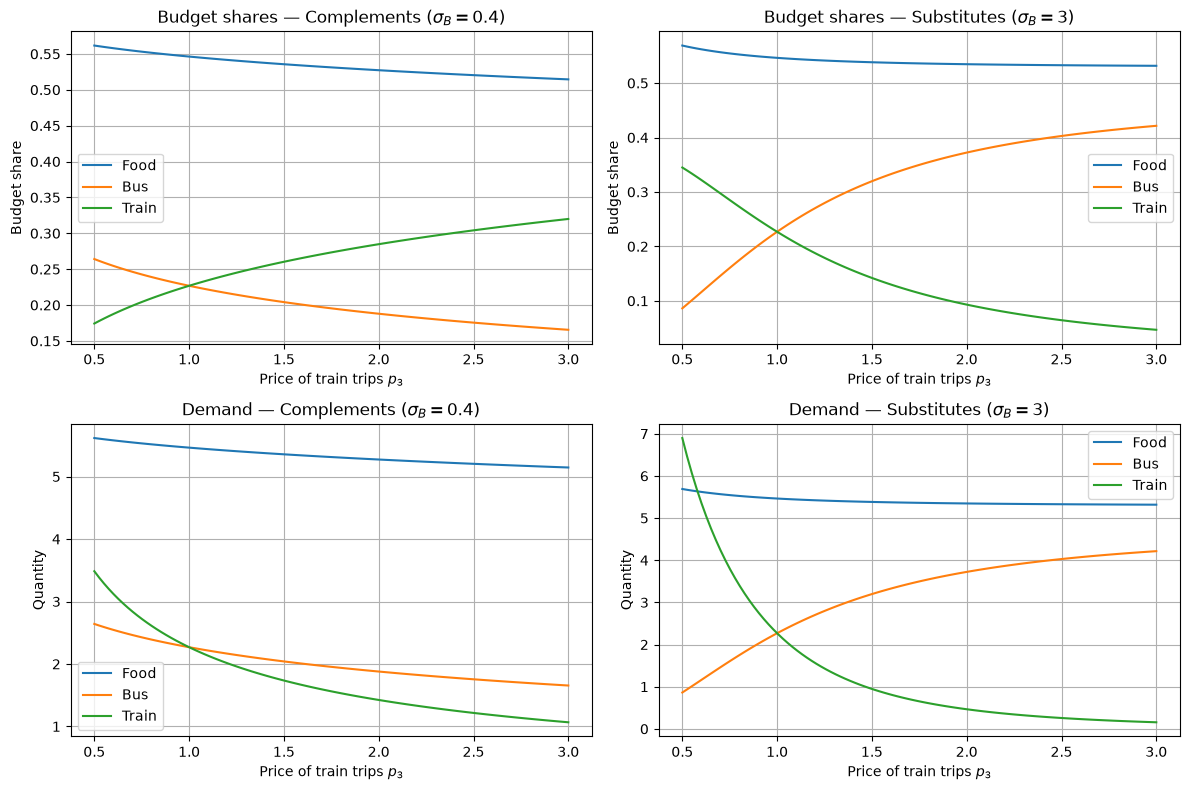

In [33]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# Budget shares - Complements
ax[0,0].plot(p3_vec, s1_comp, label='Food')
ax[0,0].plot(p3_vec, s2_comp, label='Bus')
ax[0,0].plot(p3_vec, s3_comp, label='Train')

ax[0,0].set_title('Budget shares — Complements ($\\sigma_B=0.4$)')
ax[0,0].set_xlabel('Price of train trips $p_3$')
ax[0,0].set_ylabel('Budget share')
ax[0,0].legend()
ax[0,0].grid(True)


# Budget shares - Substitutes
ax[0,1].plot(p3_vec, s1_sub, label='Food')
ax[0,1].plot(p3_vec, s2_sub, label='Bus')
ax[0,1].plot(p3_vec, s3_sub, label='Train')

ax[0,1].set_title('Budget shares — Substitutes ($\\sigma_B=3$)')
ax[0,1].set_xlabel('Price of train trips $p_3$')
ax[0,1].set_ylabel('Budget share')
ax[0,1].legend()
ax[0,1].grid(True)


# Quantities - Complements
ax[1,0].plot(p3_vec, x1_comp, label='Food')
ax[1,0].plot(p3_vec, x2_comp, label='Bus')
ax[1,0].plot(p3_vec, x3_comp, label='Train')

ax[1,0].set_title('Demand — Complements ($\\sigma_B=0.4$)')
ax[1,0].set_xlabel('Price of train trips $p_3$')
ax[1,0].set_ylabel('Quantity')
ax[1,0].legend()
ax[1,0].grid(True)


# Quantities - Substitutes
ax[1,1].plot(p3_vec, x1_sub, label='Food')
ax[1,1].plot(p3_vec, x2_sub, label='Bus')
ax[1,1].plot(p3_vec, x3_sub, label='Train')

ax[1,1].set_title('Demand — Substitutes ($\\sigma_B=3$)')
ax[1,1].set_xlabel('Price of train trips $p_3$')
ax[1,1].set_ylabel('Quantity')
ax[1,1].legend()
ax[1,1].grid(True)

plt.tight_layout()
plt.show()

The figures show that the response to a higher train price differs substantially between the two calibrations. The following questions examine these differences in more detail.

### 3.2 Train budget share

For complements, $\sigma_B = 0.4 < 1$. From the figure, the train budget share increases as `p3` increases. Even though the consumer buys fewer train trips, the higher price means that a larger share of the budget is spent on train trips.

For substitutes, $\sigma_B = 3 > 1$. Here, the train budget share decreases as `p3` increases. Since bus and train are substitutes, the consumer shifts expenditure away from the more expensive train and towards bus trips.

Therefore:
- Complements: higher `p3` increases the train budget share.
- Substitutes: higher `p3` decreases the train budget share.

### 3.3 Bus trips

For complements, $\sigma_B = 0.4$. When train tickets become more expensive, the consumer buys fewer train trips. Since bus and train are complements, the demand for bus trips also falls.

Therefore:

$p_3 \uparrow \Rightarrow x_3 \downarrow \Rightarrow x_2 \downarrow$

For substitutes, $\sigma_B = 3$. When train tickets become more expensive, the consumer substitutes away from train trips and towards bus trips.

Therefore:

$p_3 \uparrow \Rightarrow x_3 \downarrow \Rightarrow x_2 \uparrow$

The main difference is therefore that bus demand falls under complements, but increases under substitutes.

### 3.4 Demand for food

To compare the effect on food and bus demand, we calculate the percentage change in quantities between `p3 = 0.5` and `p3 = 3.0`.

In [34]:
food_change_comp = (
    (x1_comp[-1] - x1_comp[0])
    / x1_comp[0] * 100
)

bus_change_comp = (
    (x2_comp[-1] - x2_comp[0])
    / x2_comp[0] * 100
)

food_change_sub = (
    (x1_sub[-1] - x1_sub[0])
    / x1_sub[0] * 100
)

bus_change_sub = (
    (x2_sub[-1] - x2_sub[0])
    / x2_sub[0] * 100
)

print("Complements:")
print("Food:", food_change_comp, "%")
print("Bus:", bus_change_comp, "%")

print("\nSubstitutes:")
print("Food:", food_change_sub, "%")
print("Bus:", bus_change_sub, "%")

Complements:
Food: -8.393018675220478 %
Bus: -37.32920283756819 %

Substitutes:
Food: -6.5394939338980125 %
Bus: 388.8345370988778 %


Food demand changes much less than bus demand when the price of train trips increases.

For complements, food demand falls by about 8.4%, while bus demand falls by about 37.3%.

For substitutes, food demand falls by about 6.5%, while bus demand increases by about 388.8%.

The effect on bus demand is therefore much stronger than the effect on food demand. This is because bus and train are in the same travel nest, while food is outside the lower bus/train nest. A change in the train price therefore affects bus demand more directly, while food is affected indirectly through the allocation between food and travel.

# 4. Lump-sum taxes and product taxes 

This block imports the packages needed for the analysis. ```numpy``` is used for numerical calculations, ```pandas``` for creating tables, and ```matplotlib``` for plotting the results. ```GovernmentClass``` is imported from ```Government.py``` to apply the different taxes and calculate revenue and utility. The code then defines the five product-tax instruments, the two calibrations, and a grid of 101 tax rates from 0 to 3 that will be used to analyse how tax revenue changes with the tax rate.

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Government import GovernmentClass

taxes = {
    "Food": (1,),
    "Bus": (2,),
    "Train": (3,),
    "Bus + train": (2, 3),
    "All goods": (1, 2, 3)
}

calibrations = {
    "Complements": 0.40,
    "Substitutes": 3.00
}

tau_grid = np.linspace(0, 3, 101)

### 4.1. Implementation of the required methods in ```Government.py```

<br>

***The code below is written in the*** ```Government.py``` ***file instead of the first 'pass'.***
<br>
<br>
Finds how much of each good the consumer buys:

```x1, x2, x3 = self.quantities(opt.s1, opt.w)```

<br>
lump-sum tax + tax from good 1 + tax from good 2 + tax from good 3:

``` 
R = (
    par.T
    + par.tau1 * par.p1_pre * x1
    + par.tau2 * par.p2_pre * x2
    + par.tau3 * par.p3_pre * x3
) 
```


<br>



***The code below is written in the*** ```Government.py``` ***file instead of the second 'pass'.***

We are looking specifically at product taxes, so there is no lump-sum tax:
```
T = 0.0
```

Deciding wether a good is taxed. e.g. if ```goods = (1,)``` we tax food. Same goes for goods 2 and 3 (bus and train):
```
tau1 = tau if 1 in goods else 0.0
tau2 = tau if 2 in goods else 0.0
tau3 = tau if 3 in goods else 0.0
```

Applies these tax rates and updates the prices the consumer faces:
```
self.set_taxes(T=T, tau1=tau1, tau2=tau2, tau3=tau3)
```

Solves the consumer's problem with the new taxed prices:
```
opt = self.solve(do_print=False)
```

Calculates the government's total tax revenue from the consumer's choice:
```
R = self.tax_revenue(opt)
```

Saves the consumer's utility from the optimal choice:
```
u = opt.u
```


<br>


***The code below is written in the*** ```Government.py``` ***file instead of the third 'pass'.***

Sets the lump-sum tax to ```T```. No product taxes are applied:
```
self.set_taxes(T=T)
```

Finds the consumer's optimal choice after the lump-sum tax:
```
opt = self.solve(do_print=False)
````

Calculates the government's tax revenue from the lump-sum tax:
```
R = self.tax_revenue(opt)
```

Gets the consumer's utility after the tax:
```
u = opt.u
```


<br>



***The code below is written in the*** ```Government.py``` ***file instead of the fourth 'pass'.***

Creates ```N``` different tax rates between 0 and ```tau_max```:
```
tau_grid = np.linspace(0.0, tau_max, N)
````

Creates an empty array to store the revenue for each tax rate:
```
revenue_grid = np.empty(N)
```

Goes through each tax rate and gives it an index ```i```:
```
for i, tau in enumerate(tau_grid):
````

Calculates the revenue for that tax rate and stores it in ```revenue_grid```:
```
revenue_grid[i] = self.revenue_and_utility(tau, goods)[0]
````

Finds the index where the highest revenue occurs:
```
idx = np.argmax(revenue_grid)
```

Finds the tax rate that gives the highest revenue:
```
tau = tau_grid[idx]
```

Stores the maximum revenue:
```
R = revenue_grid[idx]
```


<br>


***The code below is written in the*** ```Government.py``` ***file instead of the fifth 'pass'.***

Defines a function that takes the tax rate ```tau``` and calculates how far the resulting revenue is from the target revenue:
```
def f(tau):
    R, _ = self.revenue_and_utility(tau, goods)
    return R - R_target
```

Tries to find the tax rate that gives exactly the target revenue using the Brent root-finding method:
```
try:
    res = optimize.root_scalar(
        f,
        bracket=bracket,
        method='brentq'
    )
        tau = res.root
```

If the root-finder cannot find a solution within the specified interval, it catches the error and sets the tax rate to ```np.nan```
```
except ValueError:
        tau = np.nan
```





### 4.2 Revenue as a function of the tax rate

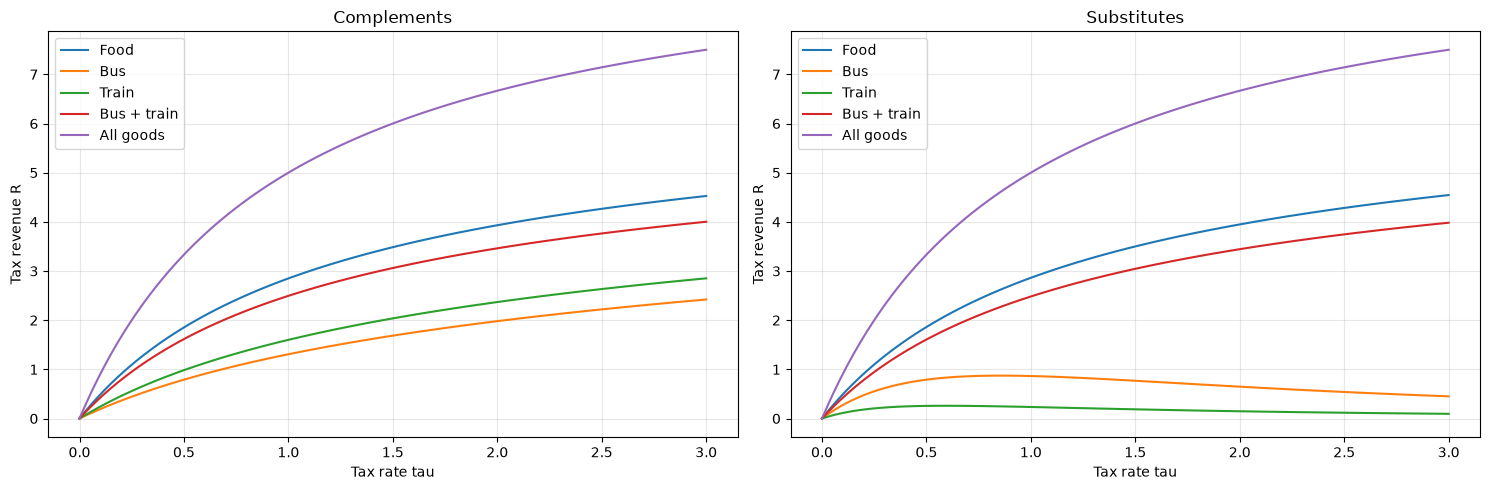

In [36]:
# Create two plots, one for each calibration
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loop over the two calibrations
for ax, (name, sigma_B) in zip(axes, calibrations.items()):
    
    # Create the government model with the given sigma_B
    model = GovernmentClass(par={"sigma_B": sigma_B})

    # Loop over the five different tax instruments
    for label, goods in taxes.items():
        
        # Calculate revenue for each tax rate
        revenue = [model.revenue_and_utility(tau, goods)[0] for tau in tau_grid]
        
        # Plot revenue against the tax rate
        ax.plot(tau_grid, revenue, label=label)

    # Add title and labels to the graph
    ax.set_title(name)
    ax.set_xlabel("Tax rate tau")
    ax.set_ylabel("Tax revenue R")
    
    # Add grid and legend
    ax.grid(alpha=0.3)
    ax.legend()

# Adjust the layout and show the graphs
plt.tight_layout()
plt.show()

### 4.3 Maximum Revenue

In the substitutes plot, the bus and train curves have a maximum (a top). These are the only curves that reach a maximum. In the other examples, all curves continue to increase over the tax-rate range shown.

In [37]:
# Create an empty list to store the results
max_results = []

# Loop over the two calibrations
for name, sigma_B in calibrations.items():
    
    # Create the government model for the calibration
    model = GovernmentClass(par={"sigma_B": sigma_B})

    # Loop over the five tax instruments
    for label, goods in taxes.items():
        
        # Find the tax rate that gives the maximum revenue
        tau_star, R_max = model.max_revenue(
            goods=goods, tau_max=3.0, N=1001
        )
        
        # Store the results
        max_results.append({
            "Calibration": name,
            "Tax": label,
            "Revenue-maximizing tau": tau_star,
            "Maximum revenue": R_max
        })

# Convert the results into a table
max_df = pd.DataFrame(max_results)

# Display the table
display(max_df)

,Calibration,Tax,Revenue-maximizing tau,Maximum revenue
0,Complements,Food,3.000,4.526108
1,Complements,Bus,3.000,2.420563
2,Complements,Train,3.000,2.850957
3,Complements,Bus + train,3.000,4.001854
4,Complements,All goods,3.000,7.500000
5,Substitutes,Food,3.000,4.544876
6,Substitutes,Bus,0.855,0.872144
7,Substitutes,Train,0.594,0.259039
8,Substitutes,Bus + train,3.000,3.982312
9,Substitutes,All goods,3.000,7.500000


**What is the most that a tax on train tickets alone can ever raise in the substitutes calibration?**

For the train tax in the substitutes calibration, the revenue-maximizing tax rate is 0.594, which gives a maximum revenue of 0.259.

### 4.4 Utility against revenue

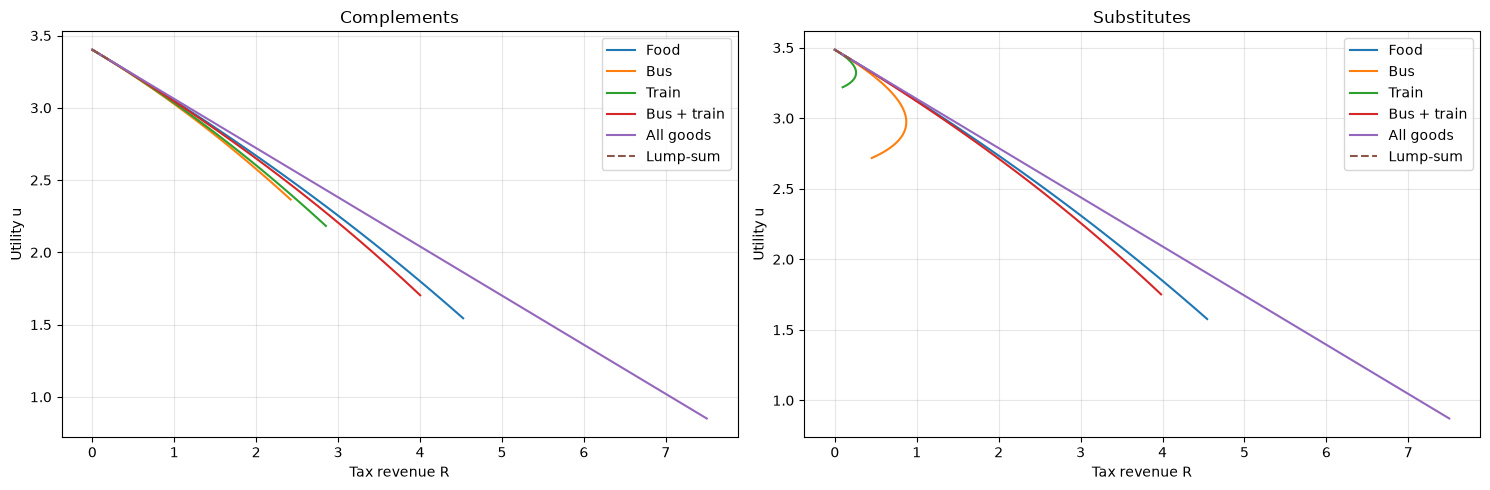

In [38]:
# Create two plots, one for each calibration
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loop over the two calibrations
for ax, (name, sigma_B) in zip(axes, calibrations.items()):

    # Create the government model for the calibration
    model = GovernmentClass(par={"sigma_B": sigma_B})

    # Loop over the five product-tax instruments
    for label, goods in taxes.items():
        revenue, utility = [], []

        # Calculate revenue and utility for each tax rate
        for tau in tau_grid:
            R, u = model.revenue_and_utility(tau, goods)
            revenue.append(R)
            utility.append(u)

        # Plot utility against revenue
        ax.plot(revenue, utility, label=label)

    # Calculate utility for different lump-sum tax levels
    R_lump = np.linspace(0, 0.20, 51)
    u_lump = [model.revenue_and_utility_lump_sum(T)[1] for T in R_lump]

    # Plot the lump-sum tax as a dashed line
    ax.plot(R_lump, u_lump, "--", label="Lump-sum")

    # Add title and axis labels
    ax.set_title(name)
    ax.set_xlabel("Tax revenue R")
    ax.set_ylabel("Utility u")

    # Add grid and legend
    ax.grid(alpha=0.3)
    ax.legend()

# Adjust the layout and show the plots
plt.tight_layout()
plt.show()

Lump-sum tax and taxing all goods are equally cheapest. Taxing all goods raises all prices proportionally, which is equivalent to reducing income through a lump-sum tax. Their curves therefore overlap.

The behavior of narrow taxes (Food, Bus, Train alone) does depend on the calibration. Under substitutes, taxing Bus pushes people onto Train so hard that at some point raising the tax rate further actually reduces revenue — Bus and Train have a peak they can't get past. Under complements, this doesn't happen; revenue just keeps rising as the tax rate increases.

### 4.5 Revenue requirement R = 0.20

In [39]:
### 4.5 Rate that hits R = 0.20 for each instrument

R_target = 0.20
tables = {}

# Loop over the two calibrations
for name, sigma_B in calibrations.items():

    # Create the government model for the calibration
    model = GovernmentClass(par={"sigma_B": sigma_B})

    rows = []
    # Loop over the five product-tax instruments
    for label, goods in taxes.items():

        # Find the tax rate that raises exactly R_target
        tau = model.find_tax_rate(R_target, goods=goods, bracket=(1e-10, 1.0))

        # Utility at that rate
        R, u = model.revenue_and_utility(tau, goods)

        rows.append({"Tax": label, "tau*": tau, "R": R, "Utility": u})

    # Rank by utility: highest utility = cheapest way to raise R_target
    df = pd.DataFrame(rows).sort_values("Utility", ascending=False).reset_index(drop=True)
    df.insert(0, "Rank", range(1, len(df) + 1))
    tables[name] = df

    print(f"=== {name} ===")
    display(df)

=== Complements ===


,Rank,Tax,tau*,R,Utility
0,1,All goods,0.020408,0.2,3.333646
1,2,Food,0.038647,0.2,3.333169
2,3,Bus + train,0.044787,0.2,3.333010
3,4,Train,0.081011,0.2,3.332548
4,5,Bus,0.104215,0.2,3.332260


=== Substitutes ===


,Rank,Tax,tau*,R,Utility
0,1,All goods,0.020408,0.2,3.415402
1,2,Food,0.038454,0.2,3.414919
2,3,Bus + train,0.045049,0.2,3.414744
3,4,Bus,0.069532,0.2,3.412375
4,5,Train,0.236217,0.2,3.395521



**Ranking**
<br>
The instruments are already ranked in the tables, sorted by utility — which is equivalent to ranking by Cost, since Cost is simply the utility gap between each instrument and the best-performing one ("All goods") at the same revenue target R = 0.20. A lower Cost means the instrument gets the consumer closer to what they could have achieved, and therefore ranks higher. 

Under ```Complements```, utilities across all five instruments are close together: the largest gap is between All goods and Bus, at 3.333646 − 3.332260 = 0.001386. Since bus and train are complements, taxing one narrow good doesn't give consumers an easy substitute to switch to, so even the worst instrument stays relatively close to the best.

Under ```Substitutes```, the spread is far wider: the largest gap is between All goods and Train, at 3.415402 − 3.395521 = 0.019881 — roughly 14 times larger than the biggest gap under Complements. Here, taxing a single good gives consumers a close substitute to escape to, which drives up the cost.

**Particular comment on the tax on train tickets:**
<br>
Taxing train tickets is cheap when travel goods are complements (no easy way to dodge the tax) but becomes the worst instrument when travel goods are substitutes, precisely because commuters can simply swap to the untaxed alternative

## 5. Extension

Bus and train are both travel, but the train is the "green" option (lower CO2 per
trip). We ask whether the government can shift the consumer's travel mix away
from the bus and towards the train *without any net cost to the treasury*: the
bus is taxed at a rate tau2, and the resulting revenue is used to subsidise the
train at a rate tau3 (a negative product tax, i.e. a lower price). For every
tau2 we use `optimize.root_scalar` — the same tool as in section 4.5 — to find
the tau3 that makes total tax revenue exactly zero.

We then trace out, for both calibrations, how the bus and train budget shares
and the consumer's utility change as the bus tax (and the matching train
subsidy) grow larger.

In [40]:
# Solve the model under a bus tax / train subsidy

def solve_with_bus_train_tax(model, tau2, tau3):
    """ solve the consumer's problem when the bus is taxed at rate tau2
    and the train is taxed/subsidised at rate tau3 (tau3 can be negative)

    Args:
        model (GovernmentClass): the model
        tau2 (float): tax rate on bus trips
        tau3 (float): tax rate on train trips (negative = subsidy)

    Returns:
        (tuple): revenue, utility, bus share, train share
    """

    # a. set the taxes and solve the consumer's problem at the resulting prices
    model.set_taxes(T=0.0, tau1=0.0, tau2=tau2, tau3=tau3)
    opt = model.solve(do_print=False)

    # b. total tax revenue (bus tax minus the cost of the train subsidy)
    R = model.tax_revenue(opt)

    return R, opt.u, opt.s2, opt.s3

In [41]:
# Find the revenue-neutral train subsidy

def find_neutral_tau3(model, tau2):
    """ find the tau3 that makes total tax revenue exactly zero, for a given tau2 """

    def revenue_gap(tau3):
        R, u, s2, s3 = solve_with_bus_train_tax(model, tau2, tau3)
        return R

    result = optimize.root_scalar(revenue_gap, bracket=(-0.9, 0.0), method='brentq')

    return result.root

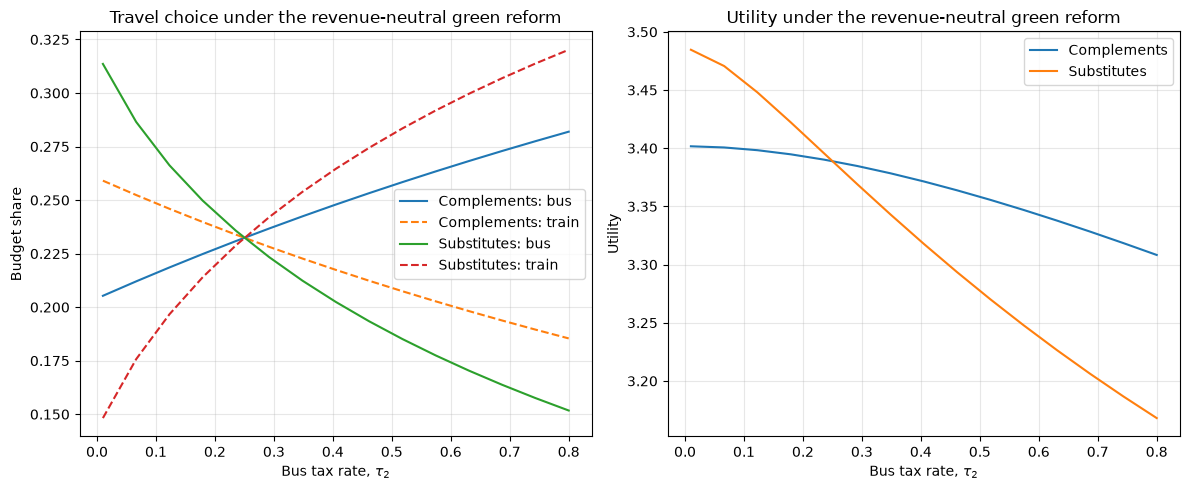

In [42]:
# We run the reform for both calibrations and plot the result

tau2_grid = np.linspace(0.01, 0.8, 15)
results = {}

for name, sigma_B in calibrations.items():

    model = GovernmentClass(par={'sigma_B': sigma_B})

    rows = []
    for tau2 in tau2_grid:

        tau3 = find_neutral_tau3(model, tau2)
        R, u, s2, s3 = solve_with_bus_train_tax(model, tau2, tau3)

        rows.append([tau2, tau3, u, s2, s3])

    results[name] = np.array(rows)

# plot: travel choice and utility as functions of the bus tax, for both calibrations
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for name, data in results.items():

    tau2_vals, tau3_vals, u_vals, s2_vals, s3_vals = data.T

    ax[0].plot(tau2_vals, s2_vals, label=f'{name}: bus')
    ax[0].plot(tau2_vals, s3_vals, '--', label=f'{name}: train')

    ax[1].plot(tau2_vals, u_vals, label=name)

ax[0].set_xlabel('Bus tax rate, $\\tau_2$')
ax[0].set_ylabel('Budget share')
ax[0].set_title('Travel choice under the revenue-neutral green reform')
ax[0].legend()
ax[0].grid(alpha=0.3)

ax[1].set_xlabel('Bus tax rate, $\\tau_2$')
ax[1].set_ylabel('Utility')
ax[1].set_title('Utility under the revenue-neutral green reform')
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

##### Conclusion 

**Conclusion**

For every bus tax rate we tried, a revenue-neutral train subsidy exists — the
government can always find a tau3 that brings total revenue back to zero.

The two calibrations, however, respond very differently:

- Under **substitutes** ($\sigma_B = 3$), the reform works as intended: the bus
  share falls from about 0.31 to 0.15, and the train share rises from about
  0.15 to 0.32, as the bus tax rises from 0.01 to 0.8. Consumers substitute
  towards the cheaper, greener option, exactly as a policymaker would hope.

- Under **complements** ($\sigma_B = 0.4$), the reform *backfires*: the bus
  share actually **rises** (from about 0.21 to 0.28) while the train share
  **falls** (from about 0.26 to 0.19). Since bus and train are complements,
  making the train cheaper raises the consumer's demand for the whole travel
  bundle, pulling *bus* trips up along with it — even though the bus itself
  has become more expensive.

In both calibrations utility falls as the reform is scaled up, even though it
raises no net revenue: shifting relative prices between two goods still
distorts the consumer's choice away from their original optimum. The loss is
much larger under substitutes (utility drops by about 0.32 at $\tau_2=0.8$)
than under complements (a drop of about 0.09), because the substitutes
consumer reacts more strongly to the changed relative price.

Thus, a "free" green tax-and-subsidy reform is not free for the
consumer, and whether it even moves demand in the intended direction depends
entirely on whether the two goods are substitutes or complements — which is the same
distinction that ran through sections 1–4 of the project.